In [79]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import flups
import scistyles
from glob import glob
import lmfit
from pyspan.utils import conv_exp, nm2ev, between, argnear
from flups.analysis import shift_trace 
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
import pandas as pd
import sympy as sy
import colorcet as cc
import seaborn as sns

In [80]:
%matplotlib widget
plt.style.use("report-sp")
%config InlineBackend.figure_format = 'svg'

# extract dispersion curve from Reference dye measurements
Measurements are available for PBBO and BBOT. 

# Load data

In [81]:
data = {
    fn.split("_")[0]: flups.io.load_txt(fn)
    for fn in ["PBBO_run0103.txt", "BBOT_run0102.txt"]
}
# t, wl, s = data
# wl = np.arange(wl.size)*0.123+244.284

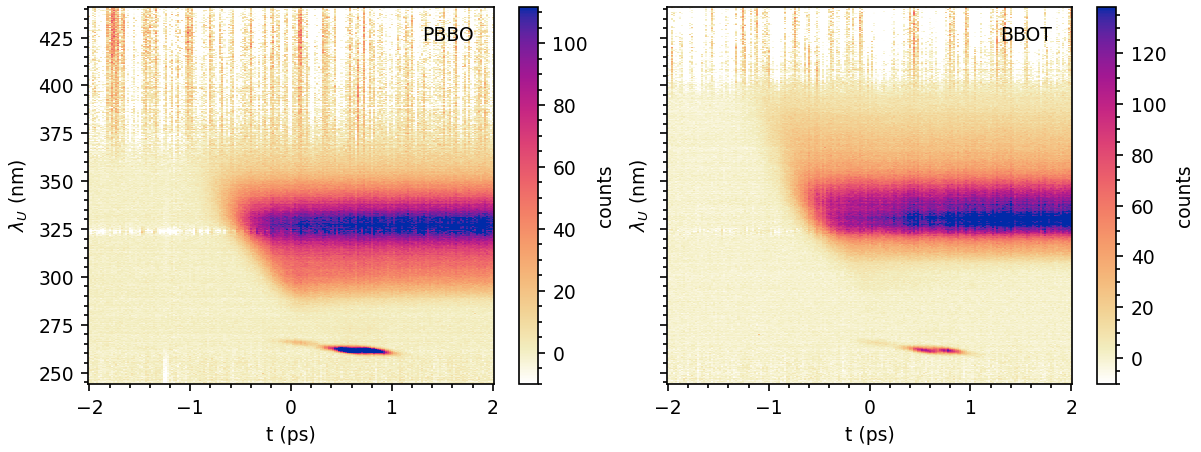

In [82]:
ncols = len(data)
fig, axes = plt.subplots(ncols=ncols, figsize=(4*ncols, 3), sharex=True, sharey=True)
vmin=-10
for ax, (fn, (t, wl, s)) in zip(axes, data.items()):
    plt.sca(ax)
    vmax = np.percentile(s, 99)
    plt.pcolormesh(t, wl, s.T, cmap="cet_CET_L17", vmin=vmin, vmax=vmax, rasterized=True)
    plt.text(0.95, 0.95, fn, ha="right", va="top", transform=ax.transAxes)
    plt.colorbar(label="counts")
    plt.xlabel("t (ps)")
    plt.ylabel(r"$\lambda_U$ (nm)")

# compute kinetics

For both samples, we compute the average in the range $[259, 263]$ nm as a measurement of the CC. At this angle, the shape is distorted (it's stretched in time), but comparisons made on 24-06-18 suggest the center position is reliable, or within a few fs.

For PBBO, take the average over bands of 5 nm in $[295,355[$ nm. For BBOT, the range is $[310, 390[$ nm.

In [83]:
# CC: 259, 263
# RAMAN: 280 - 285
# others: 285 -330
bands = {}
wl_cc = 261
for sample in data:
    bands[sample, wl_cc] = (259, 263)

for lo in range(295, 355,5):
    bands["PBBO", lo+2.5] = (lo, lo+5)

for lo in range(310, 390, 5):
    bands["BBOT", lo+2.5] = (lo, lo+5)

kins = {}
for (sample, bnd), (lo, hi) in bands.items():
    t, wl, s = data[sample]
    kins[sample, bnd] = s.compress(between(wl, lo, hi), axis=1).mean(axis=1)



# fit CC
Fit the CC to a gaussian + offset.

In [84]:
model_cc = lmfit.models.GaussianModel() + lmfit.models.ConstantModel()
guess = model_cc.make_params()
guess["amplitude"].set(value=100, min=0)
guess["center"].set(value=0.68)
guess["sigma"].set(value=0.2, min=0.02)
guess

results_cc = {}
for sample in data:
    b = (sample, wl_cc)
    k = kins[b]
    r = model_cc.fit(k, params=guess, x=t)
    print(f"{b} {r.message}")
    results_cc[b] = r

('PBBO', 261) Fit succeeded.
('BBOT', 261) Fit succeeded.


In [85]:
for k, r in results_cc.items():
    print(k, r.params["sigma"].value)

('PBBO', 261) 0.1751118255574471
('BBOT', 261) 0.17898441806650345


C:\Users\palatosa\AppData\Local\Temp\ipykernel_34612\960412881.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


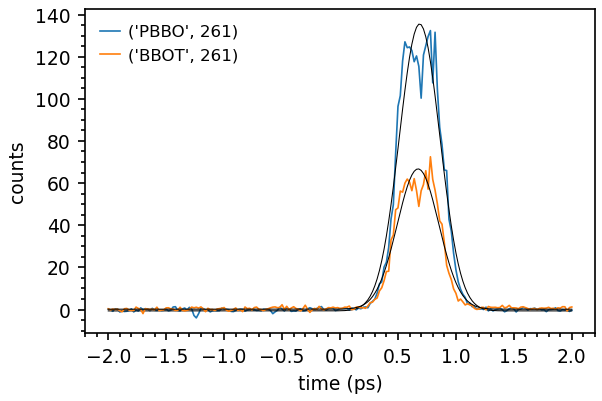

In [86]:
plt.figure()
for b, r in results_cc.items():
    plt.plot(t, kins[b], label=b)
    plt.plot(t, r.best_fit, color="k", lw=0.5)
plt.legend()
plt.xlabel("time (ps)")
plt.ylabel("counts")
None

# fit the fluorescence kinetics.
We do the fit in two passes. The model has 3 components: a single exponential decay convolved with a gaussian, a long time value (sigmoid) and a constant baseline.

In the first pass, the time constant of the single exponential decay $\tau$ is left free and independant for all kinetics. The average time constant is then computed as the weigthed average for each sample.

In the second pass, $\tau$ is kept constant for each sample. This lines up the dispersion curves *very well*.

In [87]:
# first pass. `conv_exp` contains both the single exponential and the sigmoid.
model_sig = lmfit.Model(conv_exp) + lmfit.models.ConstantModel()
guesses = {}
guess = model_sig.make_params()
guess["amp"].set(value=0, vary=True)
guess["tau"].set(value=1.0, max=5, min=0.02, vary=True)
guess["sigma"].set(value=0.2, min=0.02)
guess["t0"].set(value=-1.0)
guess["y0"].set(value=0, min=0, max=500)
guess["c"].set(value=0, min=-100, max=100)

guesses["PBBO"] = guess.copy()
guess["amp"].set(vary=True)
guess["tau"].set(vary=True)
guesses["BBOT"] = guess.copy()


results = {}
for b, k in kins.items():
    if b[1] == wl_cc: continue # is CC
    g = guesses[b[0]]
    y_ = np.mean(k[-10:])
    g["y0"].set(value=y_)
    g["c"].set(value=np.mean(k[:10]))
    m = np.isfinite(k)
    r = model_sig.fit(k[m], params=g, x=t[m])
    print(f"{b} {r.message}")
    results[b] = r

('PBBO', 297.5) Fit succeeded.
('PBBO', 302.5) Fit succeeded.
('PBBO', 307.5) Fit succeeded.
('PBBO', 312.5) Fit succeeded.
('PBBO', 317.5) Fit succeeded.
('PBBO', 322.5) Fit succeeded.
('PBBO', 327.5) Fit succeeded.
('PBBO', 332.5) Fit succeeded.
('PBBO', 337.5) Fit succeeded.
('PBBO', 342.5) Fit succeeded.
('PBBO', 347.5) Fit succeeded.
('PBBO', 352.5) Fit succeeded.
('BBOT', 312.5) Fit succeeded.
('BBOT', 317.5) Fit succeeded.
('BBOT', 322.5) Fit succeeded.
('BBOT', 327.5) Fit succeeded.
('BBOT', 332.5) Fit succeeded.
('BBOT', 337.5) Fit succeeded.
('BBOT', 342.5) Fit succeeded.
('BBOT', 347.5) Fit succeeded.
('BBOT', 352.5) Fit succeeded.
('BBOT', 357.5) Fit succeeded.
('BBOT', 362.5) Fit succeeded.
('BBOT', 367.5) Fit succeeded.
('BBOT', 372.5) Fit succeeded.
('BBOT', 377.5) Fit succeeded.
('BBOT', 382.5) Fit succeeded.
('BBOT', 387.5) Fit succeeded.


The resulting kinetics and fits.

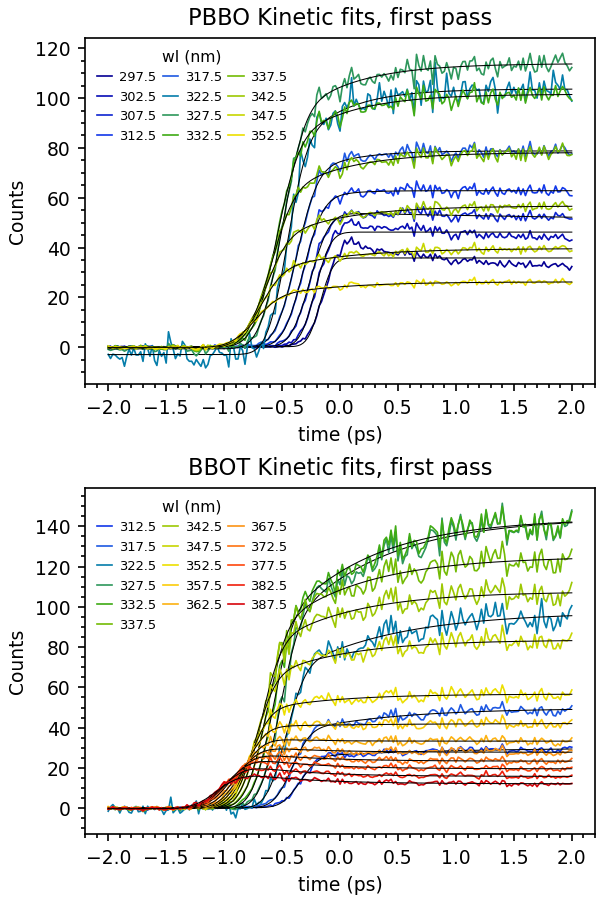

In [88]:
fig, axes = plt.subplots(nrows=len(data), figsize=(4, 3*len(data)))
axes = dict(zip(data, axes))
all_wl = sorted(list(set([k[1] for k in bands.keys()])))
colors = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(all_wl)))
colors = dict(zip(all_wl, colors))
for (sample, cwl), res in results.items():
    k = kins[sample, cwl]
    plt.sca(axes[sample])
    plt.plot(t, k, c=colors[cwl], label=cwl)
    plt.plot(t, res.best_fit, color="k", lw=0.5)
for sample, ax in axes.items():
    ax.legend(ncols=3, fontsize="x-small", title="wl (nm)", title_fontsize="small")
    ax.set_title(f"{sample} Kinetic fits, first pass")
    ax.set_xlabel("time (ps)")
    ax.set_ylabel("Counts")

In [89]:
# collect the parameters into a dataframe
t1_df = []
for (sample, cwl), r in results.items():
    if cwl == wl_cc:
        continue
    t1_df.append([sample, cwl, r.params["amp"].value, r.params["amp"].stderr, r.params["tau"].value, r.params["tau"].stderr,r.params["sigma"].value, r.params["sigma"].stderr])
t1_df = pd.DataFrame.from_records(
    t1_df,
    columns=("sample", "wl", "amp", "amp_err", "tau", "tau_err", "sigma", "sigma_err"))

Plot the parameters for the single exponential decay component.

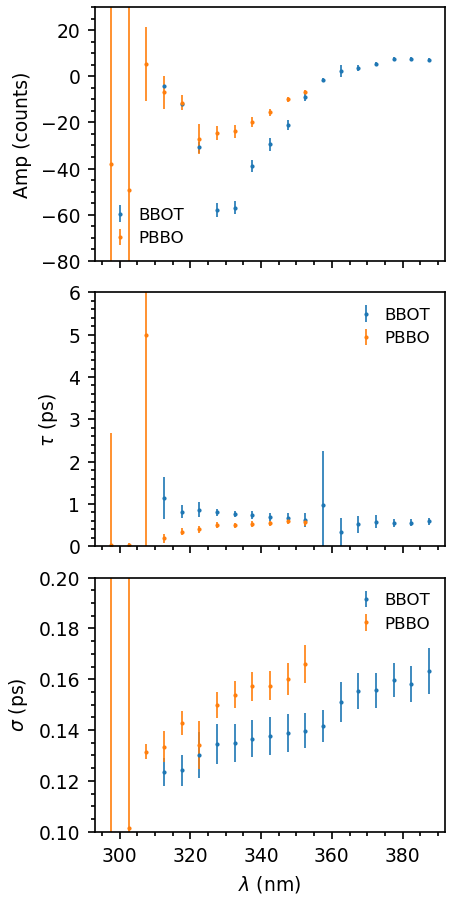

In [90]:
fig, axes = plt.subplots(nrows=3, figsize=(3,6), sharex=True)

for sample, group in t1_df.groupby(by="sample"):
    plt.sca(axes[0])
    plt.errorbar(group.wl, group.amp, group.amp_err, fmt="o", ms=1, label=sample)
    plt.sca(axes[1])
    plt.errorbar(group.wl, group.tau, group.tau_err, fmt="o", ms=1, label=sample)
    plt.sca(axes[2])
    plt.errorbar(group.wl, group.sigma, group.sigma_err, fmt="o", ms=1, label=sample)
for ax in axes:
    ax.legend(loc="best")
axes[0].set_ylim(-80, 30)
axes[0].set_ylabel("Amp (counts)")
axes[1].set_ylim(0, 6)
axes[1].set_ylabel(r"$\tau$ (ps)")
axes[2].set_ylim(0.1, 0.2)
axes[2].set_ylabel(r"$\sigma$ (ps)")
axes[-1].set_xlabel(r"$\lambda$ (nm)")
None

Compute average $\tau$, weighted by their inverse error bar.

In [91]:
# compute average tau
tau_avg = {}
for sample, group in t1_df.groupby(by="sample"):
    sel = group.query("wl>310")
    tau_avg[sample] = np.average(sel.tau, weights=1/sel.tau_err)
tau_avg

{'BBOT': 0.6754192393859816, 'PBBO': 0.47913073413039614}

# Second pass

In [92]:
model_sig = lmfit.Model(conv_exp) + lmfit.models.ConstantModel()
guesses = {}
guess = model_sig.make_params()
guess["amp"].set(value=0, vary=True)
guess["tau"].set(value=1, max=5, min=0.02, vary=False)
guess["sigma"].set(value=0.2, min=0.02)
guess["t0"].set(value=-1.0)
guess["y0"].set(value=0, min=0, max=500)
guess["c"].set(value=0, min=-100, max=100)

for sample in data:
    guesses[sample] = guess.copy()
    guesses[sample]["tau"].set(value=tau_avg[sample], vary=False)


results = {}
for b, k in kins.items():
    if b[1] == wl_cc: continue
    g = guesses[b[0]]
    y_ = np.mean(k[-10:])
    g["y0"].set(value=y_)
    g["c"].set(value=np.mean(k[:10]))
    m = np.isfinite(k)
    r = model_sig.fit(k[m], params=g, x=t[m])
    print(f"{b} {r.message}")
    results[b] = r

('PBBO', 297.5) Fit succeeded.
('PBBO', 302.5) Fit succeeded.
('PBBO', 307.5) Fit succeeded.
('PBBO', 312.5) Fit succeeded.
('PBBO', 317.5) Fit succeeded.
('PBBO', 322.5) Fit succeeded.
('PBBO', 327.5) Fit succeeded.
('PBBO', 332.5) Fit succeeded.
('PBBO', 337.5) Fit succeeded.
('PBBO', 342.5) Fit succeeded.
('PBBO', 347.5) Fit succeeded.
('PBBO', 352.5) Fit succeeded.
('BBOT', 312.5) Fit succeeded.
('BBOT', 317.5) Fit succeeded.
('BBOT', 322.5) Fit succeeded.
('BBOT', 327.5) Fit succeeded.
('BBOT', 332.5) Fit succeeded.
('BBOT', 337.5) Fit succeeded.
('BBOT', 342.5) Fit succeeded.
('BBOT', 347.5) Fit succeeded.
('BBOT', 352.5) Fit succeeded.
('BBOT', 357.5) Fit succeeded.
('BBOT', 362.5) Fit succeeded.
('BBOT', 367.5) Fit succeeded.
('BBOT', 372.5) Fit succeeded.
('BBOT', 377.5) Fit succeeded.
('BBOT', 382.5) Fit succeeded.
('BBOT', 387.5) Fit succeeded.


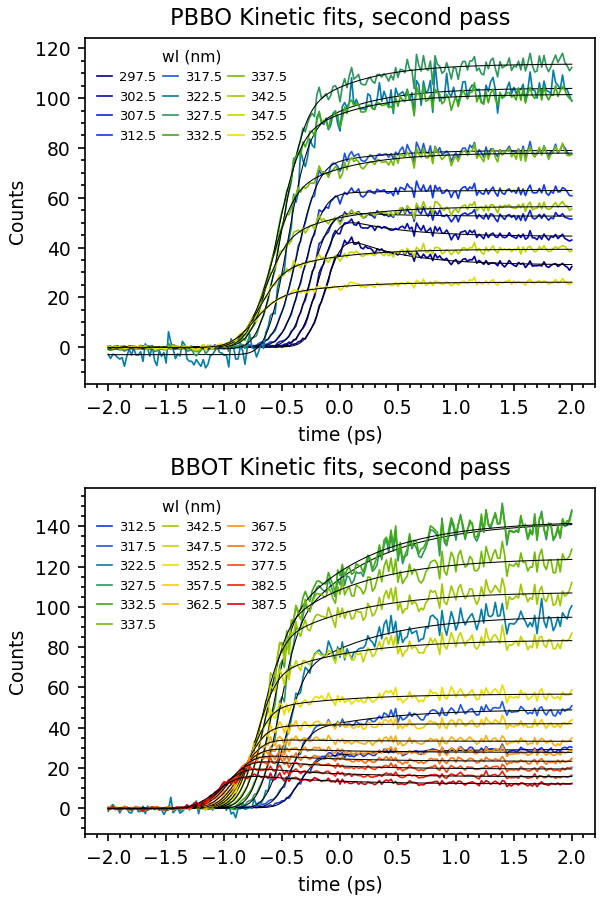

In [93]:
fig, axes = plt.subplots(nrows=len(data), figsize=(4, 3*len(data)))
axes = dict(zip(data, axes))
all_wl = sorted(list(set([k[1] for k in bands.keys()])))
colors = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(all_wl)))
colors = dict(zip(all_wl, colors))
for (sample, cwl), res in results.items():
    k = kins[sample, cwl]
    plt.sca(axes[sample])
    plt.plot(t, k, c=colors[cwl], label=cwl)
    plt.plot(t, res.best_fit, color="k", lw=0.5)
for sample, ax in axes.items():
    ax.legend(ncols=3, fontsize="x-small", title="wl (nm)", title_fontsize="small")
    ax.set_title(f"{sample} Kinetic fits, second pass")
    ax.set_xlabel("time (ps)")
    ax.set_ylabel("Counts")

Good enough for the governement.

# collect all timing determinations
The results from PBBO are offset manually by 0.02 ps to improve correspondance of the results of both measurements. These results will then be fitted by a series of models: emprical polynomials and physical models derived from the propagation of the signal through transparent media.

In [94]:
payload = [(sample, wl, r.params["t0"].value, r.params["t0"].stderr, r.params["sigma"].value,) for (sample, wl), r in results.items()]
payload.extend([(sample, wl, r.params["center"].value, r.params["center"].stderr, r.params["sigma"].value,) for (sample, wl), r in results_cc.items()])
#payload.append([282, 0.280, 0.005, np.nan]) # manual determination of Raman line
timings = pd.DataFrame.from_records(
    payload,
    columns=("sample", "wl", "t0", "t0_err", "irfw")).sort_values(by="wl")
timings["wl_f"] = 1/(1/timings.wl - 1/1340)
timings
timings_org = timings.copy()

In [95]:
timings = timings_org.copy()
timings.loc[timings["sample"] == "PBBO", "t0"] -= 0.02 # manually compensate for slight overlap


c:\Users\palatosa\miniconda3\envs\main\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


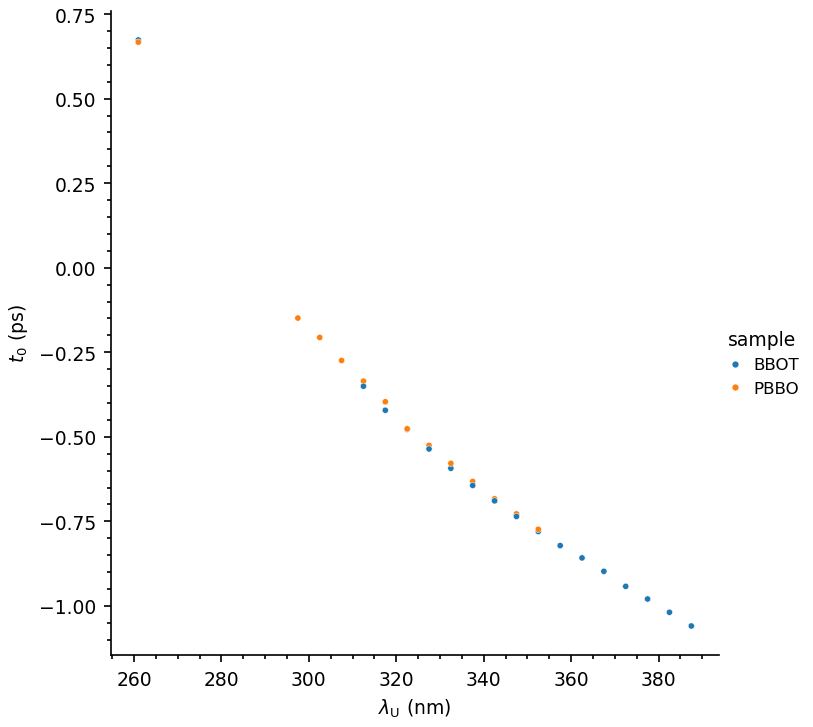

In [96]:
sns.relplot(data=timings, x="wl", y="t0", hue="sample")
plt.ylabel("$t_0$ (ps)")
plt.xlabel("$\lambda_\mathrm{U}$ (nm)")
None

# Polynomial fits
We fit polynomials in energy: 
$$
t_0 (\lambda) = \sum_{i=0}^n b_i (h c/\lambda)^i
$$
to account phenomenologically for group delay dispersion up to order n. We try n from 1 to 3.

In [97]:
polys = {}
for order in [1,2,3]:
    polys[order] = np.polyfit(nm2ev(timings.wl), timings.t0, w=1/timings.t0_err, deg=order)
t0_curves = {order: np.polyval(p, nm2ev(wl)) for order, p in polys.items()}

In [98]:
poly_tatu = np.polyfit(timings.wl**2,  timings.t0, deg=1)
t0_curves["tatu"] = np.polyval(poly_tatu, wl**2)

In [99]:
print("order, b_i")
polys

order, b_i


{1: array([ 1.11328993, -4.72022192]),
 2: array([ 0.26274593, -0.99852425, -0.52284628]),
 3: array([  0.15964171,  -1.66169105,   6.66280651, -10.59707277])}

# Sellmeier model
We build a physical model for $t_0$, where $t_0$ is obtained from the group delay and thickness of the various transparent media $a$.
$$
t_0(\lambda_\mathrm{f}) = \sum_a n_{g,a}(\lambda_\mathrm{f}) d_a/c
$$
where $n_g,a$ is the group index of material $a$, $d_a$ is the thickness of material $a$ and c is the speed of light.

The group index is obtained from the index of refraction $n$ as $n_g = n - \lambda_0 \frac{\mathrm{d}n}{\mathrm{d}\lambda_0}$, where $\lambda_0$ is the vacuum wavelength.

The indices of refraction are calculated using Sellmeier equations, or similar relations. The conversions are done symbolically using `sympy`.

In [100]:
# these are the phase indices.
# the group indices can be obtained as: n_g = n - lambda_0 * dn/dlambda_0 where lambda_0 is the vaccuum wavelength. 
from sympy.abc import x

# expression as string
n_strings = {
    "SiO2": "(1+0.6961663/(1-(0.0684043/x)**2)+0.4079426/(1-(0.1162414/x)**2)+0.8974794/(1-(9.896161/x)**2))**0.5",
    "calcite_o": "(1+0.73358749+0.96464345/(1-1.94325203e-2/x**2)+1.82831454/(1-120/x**2))**0.5",
    "calcite_e": "(1+0.35859695+0.82427830/(1-1.06689543e-2/x**2)+0.14429128/(1-120/x**2))**0.5",
    "hexane": "1.3654+3.5317e-3*x**-2+1.36906e-5*x**-4+2.3154e-6*x**-6",
    "acetonitrile": "1.33212+3.52578231e-3*x**-2-3.26316996e-5*x**-4+2.267e-6*x**-6",
    "N-WG320": "(1+0.8861/(1-9.024E-03/x**2)+0.4613/(1-8.3379E-3/x**2)+29.7610/(1-3197.045/x**2))**0.5", # from SCHOTT datasheet
}

n_expr = {k: sy.sympify(s) for k, s in n_strings.items()} # sympy expressions for n
n_lmbd = {k: sy.lambdify(x, n, "numpy") for k, n in n_expr.items()} # functions for n
ng_expr = {k: sy.simplify(n - x * sy.diff(n, x)) for k, n in n_expr.items()} # sympy expressions for n_g
ng_lmbd = {k: sy.lambdify(x, ng, "numpy") for k, ng in ng_expr.items()} # functions for n_g




In [101]:
# manual functions for checking sympy worked well. Not needed further.
def n_sio2(x):
    "x is wavelength"
    # from: https://refractiveindex.info/tmp/database/data-nk/main/SiO2/Malitson.html
    n=(1+0.6961663/(1-(0.0684043/x)**2)+0.4079426/(1-(0.1162414/x)**2)+0.8974794/(1-(9.896161/x)**2))**0.5
    return n

def n_calcite_o(x):
    "x is wavelength in um"
    # from: https://refractiveindex.info/tmp/database/data-nk/main/CaCO3/Ghosh-o.html
    n=(1+0.73358749+0.96464345/(1-1.94325203e-2/x**2)+1.82831454/(1-120/x**2))**.5
    return n

def n_calcite_e(x):
    "x is wavelength"
    # from: https://refractiveindex.info/tmp/database/data-nk/main/CaCO3/Ghosh-e.html
    n=(1+0.35859695+0.82427830/(1-1.06689543e-2/x**2)+0.14429128/(1-120/x**2))**0.5
    return n

def n_hexane(x):
    "x is wavelength in um"
    # from: https://refractiveindex.info/tmp/database/data-nk/organic/C6H14%20-%20hexane/Chang.html
    # n=(1+0.8660/(1-(0.0988/x)**2))**.5
    # https://refractiveindex.info/tmp/database/data-nk/organic/C6H14%20-%20hexane/Kozma.html
    n=1.3654+3.5317e-3*x**-2+1.36906e-5*x**-4+2.3154e-6*x**-6
    return n

def n_actonitrile(x):
    "x is wavelength in um"
    # from: https://refractiveindex.info/tmp/database/data-nk/organic/C2H3N%20-%20acetonitrile/Chang.html
    # n=(1+0.7786/(1-(0.102/x)**2))**.5
    # from: https://refractiveindex.info/tmp/database/data-nk/organic/C2H3N%20-%20acetonitrile/Kozma.html
    n=1.33212+3.52578231e-3*x**-2-3.26316996e-5*x**-4+2.267e-6*x**-6
    return n


n_pyf = {
    "SiO2": n_sio2,
    "calcite_o": n_calcite_o,
    "calcite_e": n_calcite_e,
    "hexane": n_hexane,
    "acetonitrile": n_actonitrile,
}

The plots below show the values of $n$ and $n_g$ used for the calculations.

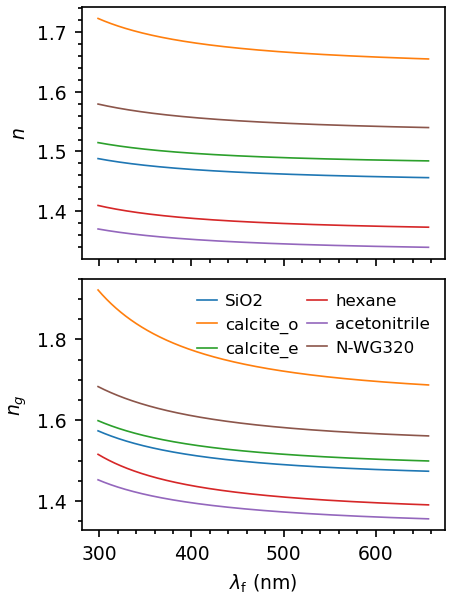

In [102]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(3,4))
wl_f = 1/(1/wl-1/1340)

plt.sca(axes[0])
for k, nf in n_lmbd.items():
    plt.plot(wl_f, nf(wl_f/1000), label=k)
plt.ylabel("$n$")

plt.sca(axes[1])
for k, ngf in ng_lmbd.items():
    plt.plot(wl_f, ngf(wl_f/1000), label=k)
plt.legend(ncols=2)
plt.ylabel("$n_g$")
plt.xlabel("$\lambda_\mathrm{f}$ (nm)")
None

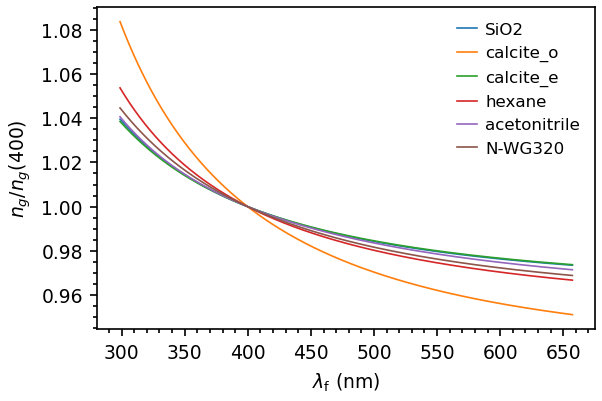

In [103]:
plt.figure()
wl_f = 1/(1/wl-1/1340)
i = argnear(wl_f, 400)
for k, ngf in ng_lmbd.items():
    ng = ngf(wl_f/1000)
    plt.plot(wl_f, ng/ng[i], label=k)
plt.legend()
plt.ylabel("$n_g$/$n_g(400)$")
plt.xlabel("$\lambda_\mathrm{f}$ (nm)")
None

The group indices are nearly proportionnal for most of the media we use. It's therefore very hard for an algorithm to diffentiate between different types of glass. We cannot, for example, include both SiO2 and acetonitrile, as this will lead to a model with degenerate parameters.

Below we try two models.  

- NWG320: using 0.2 mm fused silica, variable amount of calcite_o, 3.15 mm of NWG320 (320 filter, from Schott). We could add a bit of solvant, but its $n_g$ is too close to the other glass type.
- FS: Using a variable amount of fused silica and a variable amounf of calcite_o.

## NWG320

In [104]:
from scipy.constants import speed_of_light

def delay_sellmeier_NWG320(x, d_sio2, d_NWG320, d_cal_o, d_solvent, offset, ng_solvent=np.zeros_like):
    # thicknesses in m...
    dt = d_sio2*ng_lmbd["SiO2"](x) 
    dt += d_cal_o*ng_lmbd["calcite_o"](x)
    dt += d_NWG320*ng_lmbd["N-WG320"](x)
    dt += d_solvent * ng_solvent(x)
    dt /= speed_of_light*1E-12
    return dt + offset

def delay_sellmeier_FS(x, d_sio2, d_cal_o, offset):
    # thicknesses in m...
    dt = d_sio2*ng_lmbd["SiO2"](x) 
    dt += d_cal_o*ng_lmbd["calcite_o"](x)
    dt /= speed_of_light*1E-12
    return dt + offset

In [105]:
models = {}
results_sell = {}

In [106]:
k = "delay_sellmeier_NWG320"
models[k] = lmfit.Model(delay_sellmeier_NWG320, independent_vars=("x",), param_names=["d_sio2", "d_NWG320", "d_cal_o", "d_solvent", "offset"], n_solvent=ng_lmbd["acetonitrile"])
m = models[k]
guess = m.make_params()
guess["d_sio2"].set(value=0.2E-3, min=0E-4, max=2E-3, vary=False)
guess["d_NWG320"].set(value=3.15E-3, min=3.15E-3, vary=False)
guess["d_cal_o"].set(value=3E-3, min=0.5E-3, max=5E-3, vary=True)
guess["d_solvent"].set(value=0E-4, min=0, max=1E-3, vary=False)
guess["offset"].set(value=-19.76)
#guess

The NWG320 uses 0.2 mm of FS (exit window), a 3.15 mm of NWG320 (filter) and a variable amount of calcite. After fitting, the thickness of calcite is estimated at 1.4 mm, which is reasonable considering experimental geometry. Marco measures between 1 and 1.5 mm for the central ray.

In [107]:
results_sell[k] = m.fit(timings.t0, 
                        params=guess, 
                        weights=1/timings.t0_err, 
                        x=timings.wl_f/1000,
                        method="Nelder"
                       )
r = results_sell[k]
print(lmfit.fit_report(r))

[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 145
    # data points      = 30
    # variables        = 2
    chi-square         = 329.669657
    reduced chi-square = 11.7739163
    Akaike info crit   = 75.9068120
    Bayesian info crit = 78.7092067
    R-squared          = -67.6889017
[[Variables]]
    d_sio2:     0.0002 (fixed)
    d_NWG320:   0.00315 (fixed)
    d_cal_o:    0.00146029 +/- 1.6735e-05 (1.15%) (init = 0.003)
    d_solvent:  0 (fixed)
    offset:    -26.8689157 +/- 0.09876469 (0.37%) (init = -19.76)
[[Correlations]] (unreported correlations are < 0.100)
    C(d_cal_o, offset) = -0.9997


## FS

This model results in 2.6 mm of calcite, which is unreasonable experimentally.

In [108]:
k = "delay_sellmeier_FS"
models[k] = lmfit.Model(delay_sellmeier_FS, independent_vars=("x",), param_names=["d_sio2",  "d_cal_o", "offset"])
m = models[k]
guess = m.make_params()
guess["d_sio2"].set(value=0.2E-3, min=0E-4, max=10E-3, vary=True)
guess["d_cal_o"].set(value=2E-3, min=0.0E-3, max=5E-3)
guess["offset"].set(value=-19.76)
#guess

In [109]:
results_sell[k] = m.fit(timings.t0, 
                                       params=guess, 
                                       weights=1/timings.t0_err, 
                                       x=timings.wl_f/1000,
                                       method="Nelder"
                                      )
r = results_sell[k]

In [110]:
print(lmfit.fit_report(r))

[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 482
    # data points      = 30
    # variables        = 3
    chi-square         = 531.502755
    reduced chi-square = 19.6852872
    Akaike info crit   = 92.2353300
    Bayesian info crit = 96.4389221
    R-squared          = -109.742192
[[Variables]]
    d_sio2:   0.00140654 +/- 0.00410817 (292.08%) (init = 0.0002)
    d_cal_o:  0.00260097 +/- 0.00176832 (67.99%) (init = 0.002)
    offset:  -22.7873015 +/- 10.2760400 (45.10%) (init = -19.76)
[[Correlations]] (unreported correlations are < 0.100)
    C(d_sio2, d_cal_o) = -0.9999
    C(d_sio2, offset)  = -0.9999
    C(d_cal_o, offset) = +0.9997


# Overall results - Does any of this matter?


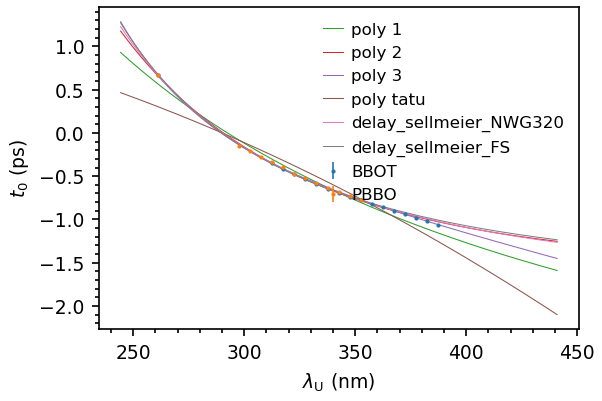

In [111]:
plt.figure()
for sample, group in timings.groupby("sample"):
    plt.errorbar(group.wl, group.t0, yerr=group.t0_err, fmt="o", ms=1, label=sample)
for o, c in t0_curves.items():
    plt.plot(wl, c, label=f"poly {o}", lw=0.5)
for k, r in results_sell.items():
    plt.plot(wl, r.eval(r.params, x=wl_f/1000), label=k, lw=0.5)
plt.legend()
plt.xlabel("$\lambda_\mathrm{U}$ (nm)")
plt.ylabel("$t_0$ (ps)")
None

The plot above compares the experimental points with the various models. Most do fit quite well. The $t_0$ values for BBOT at long wavelengths seem to come too early, but that could be a sample property, or a fitting artefact.

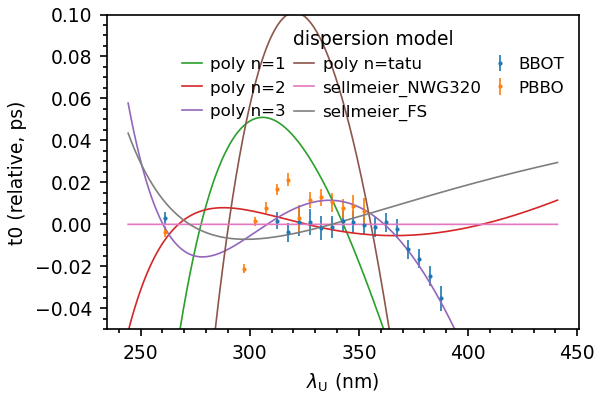

In [112]:
# compare to NWG320 as a reference

r_ref = results_sell["delay_sellmeier_NWG320"]
c_ref = r_ref.eval(r_ref.params, x=wl_f/1000)
plt.figure()

#plt.errorbar(timings.wl, timings.t0-r_ref.best_fit, timings.t0_err, fmt="o", ms=1, label="data")
for sample, group in timings.groupby("sample"):
    plt.errorbar(group.wl, group.t0-r_ref.eval(r_ref.params, x=group.wl_f/1000), yerr=group.t0_err, fmt="o", ms=1, label=sample)
for o, c in t0_curves.items():
    plt.plot(wl, c-c_ref, label=f"poly n={o}")
for k, r in results_sell.items():
    plt.plot(wl, r.eval(r.params, x=wl_f/1000)-c_ref, label=k[6:])
plt.legend(title = "dispersion model", ncols=3, fontsize=8)
plt.ylim(-0.05, 0.1)
plt.xlabel(r"$\lambda_\mathrm{U}$ (nm)")
plt.ylabel("t0 (relative, ps)")
None

Here we compare the difference in the predictions of the various models, taking the Sellmeier model with NWG320 as a reference. Overall, predictions are within *40 fs* of each other, which is 2 pixels. They're all pretty much good.

The Seillmeier NWG320 is preferred as it has two parameters, is physicially justified and yields very good results over most of the range. Its output (calcite thickness of 1.46 mm) is also highly consistent with the experimental geometry.

The third order polynomial yields a better fit, but we will need to extrapolate, and polynomials are bad at this.

There are two issues plaguing our analysis:

1. The CC has a lot of weight as it is alone on the blue edge. However, the CC is somewhat distorted at this angle. The use of a Raman line, when available, would be preferred.

2. The behavior of BBOT at higher wavelengths (4 pts) deviates from the trend, they are too early. This could be a physical effect or a fitting artefact. After all, we are pumping this one with a lot of excess energy. These points tend to force the Sellmeier models to favor FS unreasonably.


In [113]:
shifted = {}
for fn, (t, wl, s) in data.items():
    t_c, s_s = shift_trace(t, s.T, t0c)
    shifted[fn] = (t_c, wl, s_s.T)

NameError: name 't0c' is not defined

KeyError: 'PBBO'

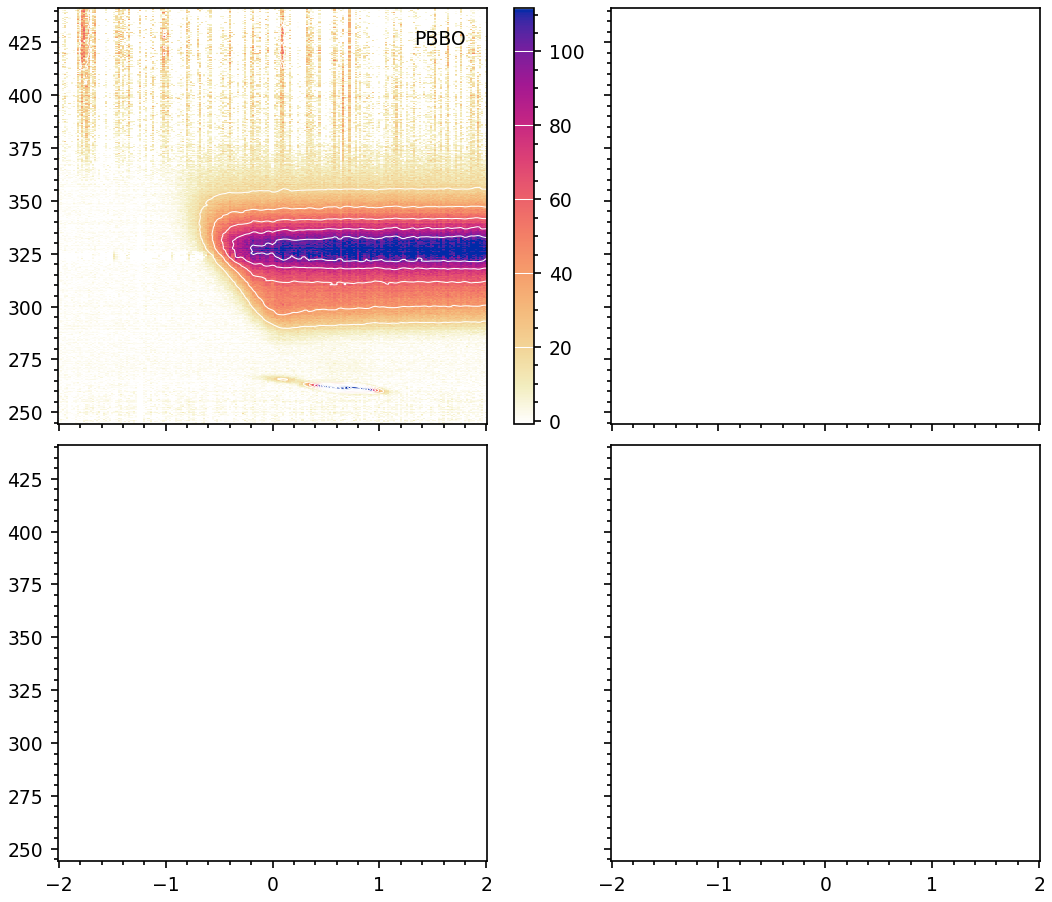

In [ ]:
ncols = len(data)
nrows = 2
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(3.5*ncols, 3*nrows), sharex=True, sharey=True)
vmin=-1
t0c = results_sell["delay_sellmeier_NWG320"].eval(x=wl_f/1000)
for i, (fn, (t, wl, s)) in enumerate(data.items()):
    plt.sca(axes[0,i])
    vmax = np.percentile(s, 99)
    plt.pcolormesh(t, wl, s.T, cmap="cet_CET_L17", vmin=vmin, vmax=vmax, rasterized=True)
    cb = plt.colorbar()
    lines = plt.contour(t, wl, gaussian_filter(s.T, [3, 1]), levels = np.arange(0, vmax*2,20)[1:], colors="w", linewidths=0.5)
    plt.text(0.95, 0.95, fn, ha="right", va="top", transform=plt.gca().transAxes)
    cb.add_lines(lines)

    plt.sca(axes[1,i])
    t_s, wl, s_s = shifted[fn]
    plt.pcolormesh(t_s, wl, s_s.T, cmap="cet_CET_L17", vmin=vmin, vmax=vmax, rasterized=True)
    cb = plt.colorbar()
    lines = plt.contour(t_s, wl, gaussian_filter(s_s.T, [3, 1]), levels = np.arange(0, vmax*2,20)[1:], colors="w", linewidths=0.5)
    plt.text(0.95, 0.95, fn, ha="right", va="top", transform=plt.gca().transAxes)
    cb.add_lines(lines)
for ax in axes[0,:]:
    plt.sca(ax)
    for sample, group in timings.groupby("sample"):
        plt.errorbar(group.t0, group.wl, xerr=group.t0_err, fmt="o", ms=1, label=sample)
    for o, c in t0_curves.items():
        plt.plot(c, wl, label=f"poly n={o}")
    for k, r in results_sell.items():
        plt.plot(r.eval(r.params, x=wl_f/1000), wl, label=k[6:])

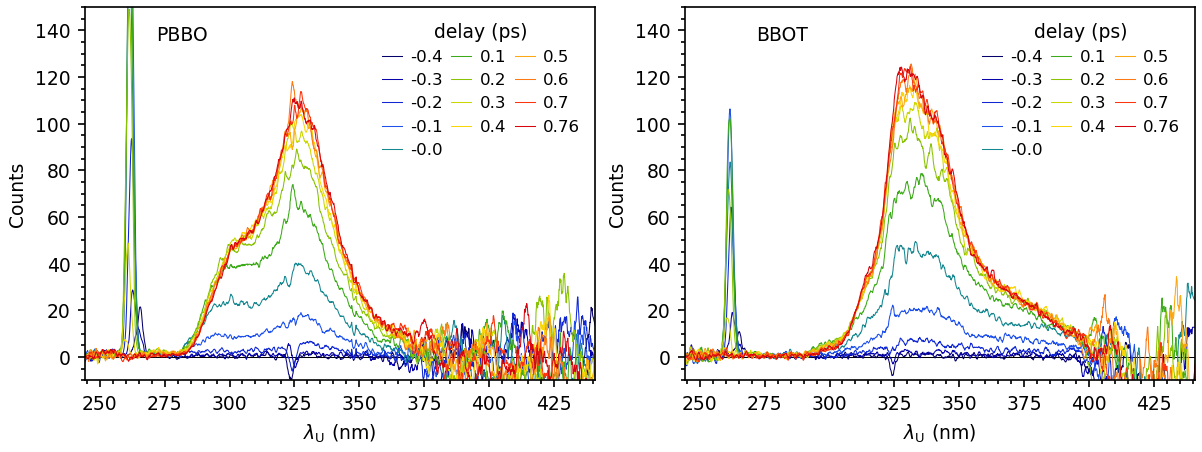

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(8,3))
selected = np.arange(-0.4, 0.8001, 0.1)
palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(selected)))
palette = dict(zip(selected, palette))
for sample, ax in zip(shifted, axes):
    plt.sca(ax)
    plt.axhline(0, color="k", lw=0.5)
    t, wl, s = shifted[sample]
    for s_ in selected:
        i = argnear(t, s_)
        plt.plot(wl, savgol_filter(s[i,:], 15, 2), color=palette[s_], label=t[i], lw=0.5)
    plt.ylim(-10, 150)
    plt.text(0.14, 0.95, sample, ha="left", va="top", transform=ax.transAxes)
    plt.legend(ncols=3, title="delay (ps)")
    plt.xlabel(r"$\lambda_\mathrm{U}$ (nm)")
    plt.xlim(wl[0], wl[-1])
    plt.ylabel("Counts")
plt.savefig("240624_dispersion_references_corrected.png", dpi=600)
plt.savefig("240624_dispersion_references_corrected.svg", dpi=600)

In [ ]:
# ok, let's just save this one. All the fooling around doesn't change much..
t0c = results_sell["delay_sellmeier_NWG320"].eval(x=wl_f/1000)
np.savetxt("240624_t0_sell_NWG320.txt", np.vstack([wl, t0c]).T)

In [ ]:
assert False # prevent autorunning the long calculation

AssertionError: 

# Estimation of confidence
We generate 5000 samples using MCMC.

In [ ]:
# try mcmc
p = results_sell["delay_sellmeier_NWG320"].params.copy()
m = models["delay_sellmeier_NWG320"]
emcee_pars = dict(burn=300, thin=10, steps=5000, is_weighted=False, progress=True)
p.add("__lnsigma", value=1.24488572, min=0) ## looks like ln(chi_r)
res_mcmc = m.fit(
    timings.t0, 
    params=p,
    weights=1/timings.t0_err,
    x=timings.wl_f/1000,
    method="emcee",
    fit_kws=emcee_pars
)

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [02:39<00:00, 31.43it/s]


In [ ]:
print(lmfit.fit_report(res_mcmc))

[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 500000
    # data points      = 30
    # variables        = 3
    chi-square         = 27.3749311
    reduced chi-square = 1.01388634
    Akaike info crit   = 3.25290864
    Bayesian info crit = 7.45650079
    R-squared          = -4.70375195
[[Variables]]
    d_sio2:     0.0002 (fixed)
    d_NWG320:   0.00315 (fixed)
    d_cal_o:    0.00146027 +/- 1.7101e-05 (1.17%) (init = 0.001460294)
    d_solvent:  0 (fixed)
    offset:    -26.8687867 +/- 0.10100746 (0.38%) (init = -26.86892)
    __lnsigma:  1.24423199 +/- 0.13452355 (10.81%) (init = 1.244886)
[[Correlations]] (unreported correlations are < 0.100)
    C(d_cal_o, offset) = -0.9997


C:\Users\palatosa\miniconda3\envs\main\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


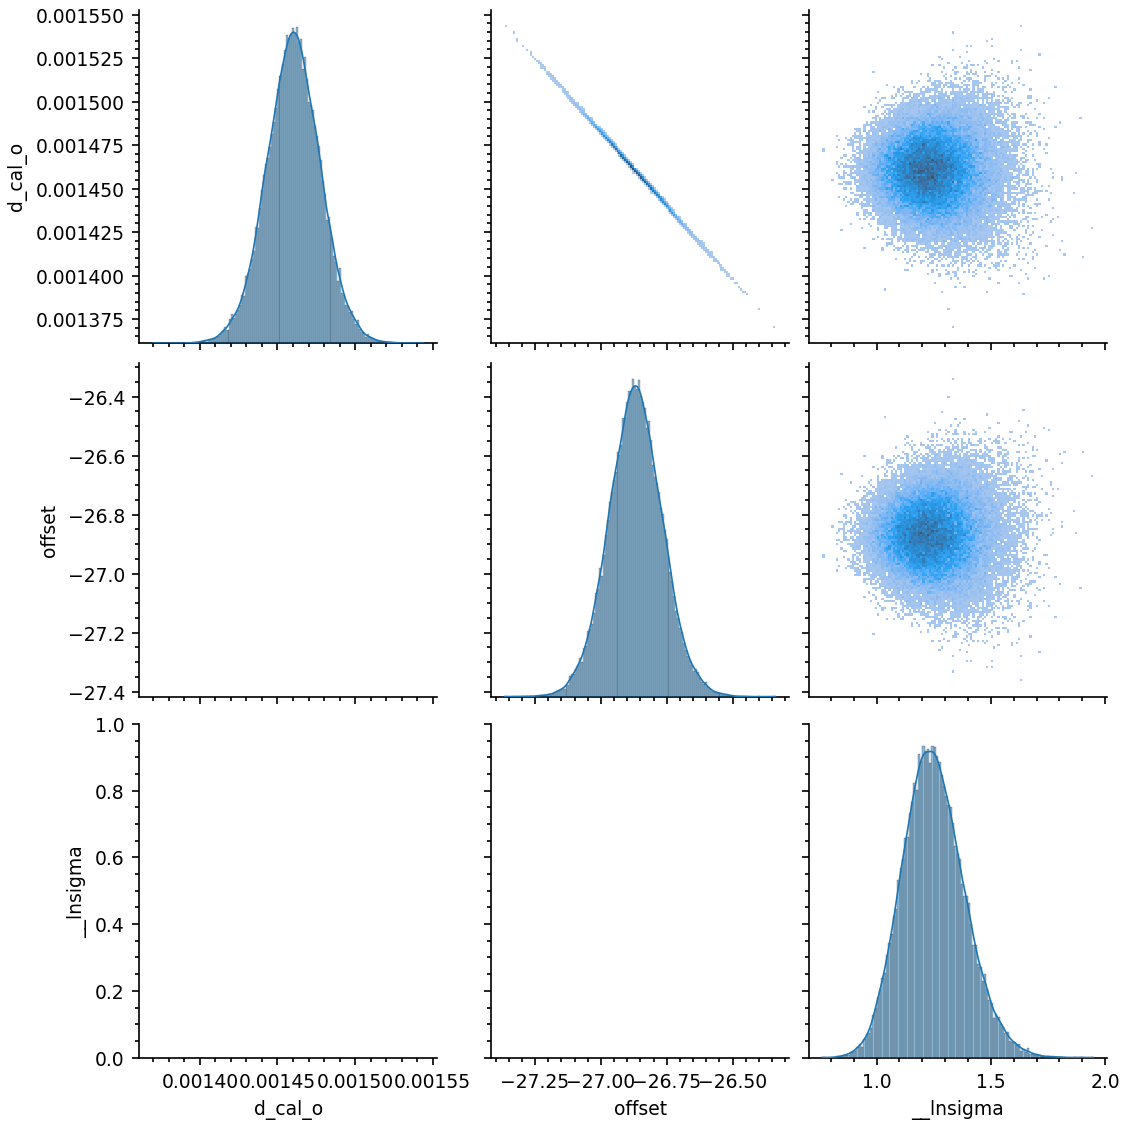

In [ ]:
g = sns.PairGrid(res_mcmc.flatchain)
g.map_diag(sns.histplot, kde=True)
g.map_upper(sns.histplot)
plt.gcf().set_constrained_layout(True)

The graph above is the distribution of parameters, and their joint distribtion. `__lnsigma` is an error parameter, necessary as our $\chi_r^2$ isn't actually close to 1 (but instead 11).

In [ ]:
res_mcmc.flatchain

,d_cal_o,offset,__lnsigma
0,0.001426,-26.663035,1.263757
1,0.001452,-26.819126,1.352519
2,0.001435,-26.717427,1.248889
3,0.001461,-26.873577,1.425080
4,0.001486,-27.022580,1.328483
...,...,...,...
46995,0.001478,-26.969258,1.406017
46996,0.001435,-26.718640,1.434067
46997,0.001427,-26.677071,1.407830
46998,0.001471,-26.936519,1.431794


In [ ]:
subset = res_mcmc.flatchain.sample(n=1000).copy()
ps = subset.to_numpy()
curves = np.apply_along_axis(lambda r: 
                                                        delay_sellmeier_NWG320(
                                                            wl_f/1000, 
                                                            res_mcmc.params["d_sio2"].value,
                                                            res_mcmc.params["d_NWG320"].value,
                                                            r[0], res_mcmc.params["d_solvent"].value, r[1],
                                                            ng_solvent=ng_lmbd["acetonitrile"]),
                  axis=1, arr=ps)
means = np.mean(curves, axis=0)
mrgn = np.std(curves, axis=0)

From this sample, we draw a subset of 1000 points, and we compute the delay curve using our model (NWG320) for each of these. We plot the average value and the $\pm\sigma$ intervals. The intervals are too narrow to be seen on the graph, so we plot the std deviation separately. The statistical precision isn't the limiting factor here...

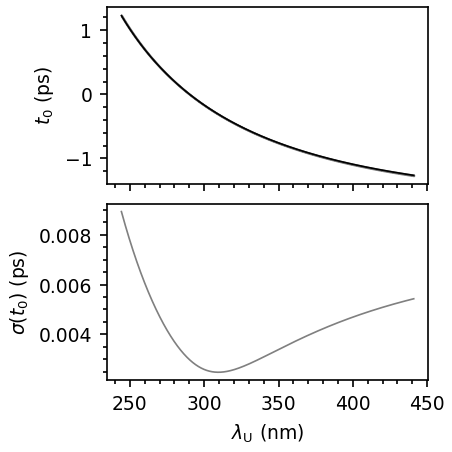

In [ ]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(3,3))
plt.sca(axes[0])
plt.plot(wl, means, color="k")
plt.fill_between(wl, means+mrgn, means-mrgn, color="0.5")

plt.ylabel("$t_0$ (ps)")
plt.sca(axes[1])
plt.plot(wl, mrgn, color="0.5")
plt.xlabel(r"$\lambda_\mathrm{U}$ (nm)")
plt.ylabel("$\sigma(t_0)$ (ps)")
None